## Introduction ##

##### This dataset provides detailed information about retail customers and their purchasing behavior. It captures key aspects of customers’ demographics, buying habits, engagement with marketing, loyalty, and transaction details.

##### Key features include customer demographics such as age, gender, income level, education, occupation, and location; purchase behavior including product categories, purchase amounts, frequency, purchase channels, brand loyalty, and payment methods; and marketing engagement such as time spent on product research, social media influence, discount sensitivity, and device used for shopping. The dataset also contains information about customer loyalty, satisfaction, and decision-making, including loyalty program membership, customer satisfaction ratings, purchase intent, shipping preference, and time taken to make a purchase.

##### Analyzing this dataset can help businesses identify trends, understand customer preferences, optimize marketing strategies, improve product offerings, and increase overall sales. It provides a comprehensive view of the customer journey and enables data-driven decision-making.

#### Import Dataset and Necessary Files

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
df=pd.read_csv(r"D:\DATA SCIENCE SMEC\Datas for working\Ecommerce_Consumer_Behavior_Analysis_Unclean.csv") #Reading the .csv file for cleaning and analyzing 

#### Overview of the data

In [2]:
df #Overview of the data

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,"22.0,00",Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,$333.80,...,7.0,None,Tablet,CREDIT CARD,3/1/2024,True,False,Need-based,No Preference,2.0
1,29-392-9296,49.0,Male,High,Married,High School,High,Huocheng,Food & Beverages,$222.22,...,5.0,High,tablet,PayPal,4/16/2024,True,False,Wants-based,Standard,6.0
2,84-649-5117,24.0,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,$426.22,...,7.0,Low,Smartphone,Debit Card,3/15/2024,True,True,Impulsive,No Preference,NaN
3,48-980-6078,29.0,Female,Middle,Single,MASTER'S,Middle,Wiwilí,Home Appliances,$101.31,...,NaN,None,Smartphone,OTHER,10/4/2024,True,True,Need-Based,express,10.00
4,91-170-9072,33.0,Female,Middle,Widowed,High School,Middle,Nara,Furniture,$211.70,...,10.0,None,Smartphone,Debit Card,1/30/2024,False,False,Wants-based,No Preference,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,81-926-9297,22.0,female,Middle,widowed,Master's,High,Gävle,Packages),$193.94,...,3.0,High,Desktop,Other,8/9/2024,False,False,Wants-based,Standard,9.0
1011,30-567-4471,34.0,MALE,Middle,Married,Bachelor's,Middle,Parumasan,Clothing,$373.69,...,8.0,NONE,Tablet,Credit Card,12/4/2024,False,True,IMPULSIVE,express,14.0
1012,63-808-3641,25.0,Male,High,Widowed,Bachelor's,Middle,Pointe Michel,Home Appliances,$222.61,...,1.0,None,Desktop,PayPal,7/3/2024,False,True,Need-based,Standard,3.0
1013,78-091-8662,43.0,Male,High,divorced,High School,Middle,Prengtale,Gardening & Outdoors,$141.63,...,8.0,Low,Smartphone,Cash,10/11/2024,True,True,Planned,Express,11.0


#### Data Cleaning

In [3]:
# Check whether there are any missing values
df.isnull().sum() 

Customer_ID                                0
Age                                      128
Gender                                     0
Income_Level                               0
Marital_Status                             0
Education_Level                            0
Occupation                                 0
Location                                   0
Purchase_Category                          0
Purchase_Amount                            0
Frequency_of_Purchase                    161
Purchase_Channel                           0
Brand_Loyalty                            149
Product_Rating                           129
Time_Spent_on_Product_Research(hours)    157
Social_Media_Influence                     0
Discount_Sensitivity                       0
Return_Rate                              123
Customer_Satisfaction                    162
Engagement_with_Ads                        0
Device_Used_for_Shopping                   0
Payment_Method                             0
Time_of_Pu

In [4]:
#viewing the Age column
df['Age']

0       22.0,00
1          49.0
2          24.0
3          29.0
4          33.0
         ...   
1010       22.0
1011       34.0
1012       25.0
1013       43.0
1014       43.0
Name: Age, Length: 1015, dtype: object

In [5]:
#Viewing the uniques values of the 'Age' colunm unsing unique() function which help to understanding any noisy values occur
df['Age'].unique() 

array(['22.0,00', '49.0', '24.0', '29.0', '33.0', '45.0', '21.0', '39.0',
       '25.0', '38.0', nan, '32.0', '30.0', '40.0', '36.0', '37.0',
       '31.0', '50.0', '48.0', '34.0', '46.0', '43.0', '42.0', '40.0,00',
       '35.0', '27.0', '19.0', '$46.0', '23.0', '20.0', '41.0', '26.0',
       '18.0', '22.0', '28.0', '47.0', '39.00', '31.0,00', '35.00',
       '$44.0', '$39.0', '44.0', '29.0,00', '37.0,00', '28.0,00', '$26.0',
       '42.0,00', '$18.0', '31.00', '22.00', '48.00', '19.0,00',
       '38.0,00', '45.0,00', '$37.0', '49.00', '43.00', '$34.0',
       '49.0,00', '42.00', '$40.0', '46.00', '$50.0', '41.0,00', '21.00',
       '23.0,00', '29.00'], dtype=object)

##### Replacing unwanted portions and symbols

In [6]:
df['Age']=df['Age'].str.replace('.0,00','',regex=False) #value like 22.0,00
df['Age']=df['Age'].str.replace(',','',regex=False)
df['Age']=df['Age'].str.replace('$','',regex=False) #values like $40.0


In [7]:
#Changing the datatype to float from
df['Age']=df['Age'].astype(float)
df['Age'] = df['Age'].fillna(df['Age'].median())

In [8]:
df['Frequency_of_Purchase']

0        4.0
1        NaN
2        2.0
3        6.0
4        6.0
        ... 
1010    11.0
1011    10.0
1012     3.0
1013     NaN
1014    10.0
Name: Frequency_of_Purchase, Length: 1015, dtype: object

In [9]:
df=df[df['Frequency_of_Purchase'].str.len()<4]

In [10]:
df['Frequency_of_Purchase']=df['Frequency_of_Purchase'].astype('float')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3281214777.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Frequency_of_Purchase']=df['Frequency_of_Purchase'].astype('float')


In [11]:
df['Frequency_of_Purchase'].count()

579

In [12]:
df['Frequency_of_Purchase']

0       4.0
2       2.0
3       6.0
4       6.0
5       8.0
       ... 
999     6.0
1002    7.0
1008    4.0
1009    4.0
1012    3.0
Name: Frequency_of_Purchase, Length: 579, dtype: float64

In [13]:
df['Gender'].unique()

array(['Female', 'Male', 'Bigender', 'Genderfluid', ' Female ', 'FEMALE',
       'Polygender', 'female', ' Genderfluid ', 'BIGENDER', 'MALE',
       ' Male ', 'non-binary', 'Genderqueer', 'male', 'Agender',
       'GENDERFLUID', 'Non-binary', 'GENDERQUEER', 'Non-Binary',
       'genderfluid'], dtype=object)

In [14]:
df['Gender']=df['Gender'].str.strip().str.lower()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2133680446.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender']=df['Gender'].str.strip().str.lower()


In [15]:
df['Gender']=df['Gender'].replace({'female':'Female','male':'Male'})
df['Gender'] = df['Gender'].where(df['Gender'].isin(['Male', 'Female']))
df['Gender'] = df['Gender'].ffill()



C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\66204682.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender']=df['Gender'].replace({'female':'Female','male':'Male'})
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\66204682.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].where(df['Gender'].isin(['Male', 'Female']))
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\66204682.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFram

In [16]:
df['Gender'].head(30)

0     Female
2     Female
3     Female
4     Female
5       Male
7       Male
9       Male
13      Male
15      Male
16      Male
20    Female
21    Female
22      Male
23    Female
24    Female
25      Male
28      Male
30    Female
31      Male
32      Male
35    Female
36      Male
37    Female
38    Female
39      Male
40    Female
41    Female
42      Male
45    Female
46    Female
Name: Gender, dtype: object

In [17]:
df['Gender'].isnull().sum()

0

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            579 non-null    object 
 1   Age                                    579 non-null    float64
 2   Gender                                 579 non-null    object 
 3   Income_Level                           579 non-null    object 
 4   Marital_Status                         579 non-null    object 
 5   Education_Level                        579 non-null    object 
 6   Occupation                             579 non-null    object 
 7   Location                               579 non-null    object 
 8   Purchase_Category                      579 non-null    object 
 9   Purchase_Amount                        579 non-null    object 
 10  Frequency_of_Purchase                  579 non-null    float64
 11  Purch

In [19]:
df['Income_Level']

0       Middle
2       Middle
3       Middle
4       Middle
5       Middle
         ...  
999     Middle
1002      High
1008    MIDDLE
1009      High
1012      High
Name: Income_Level, Length: 579, dtype: object

In [20]:
df['Income_Level'].unique()

array(['Middle', 'High', 'middle', 'high', ' High ', ' Middle ', 'MIDDLE',
       'HIGH'], dtype=object)

In [21]:
df['Income_Level']=df['Income_Level'].str.strip().str.lower()
df['Income_Level']=df['Income_Level'].replace({'middle':'Middle','high':'High'})

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1075765475.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income_Level']=df['Income_Level'].str.strip().str.lower()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1075765475.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Income_Level']=df['Income_Level'].replace({'middle':'Middle','high':'High'})


In [22]:
df['Marital_Status']

0        Married
2         Single
3         Single
4        Widowed
5        married
          ...   
999      Single 
1002     married
1008    Divorced
1009     Widowed
1012     Widowed
Name: Marital_Status, Length: 579, dtype: object

In [23]:
df['Marital_Status']=df['Marital_Status'].str.strip().str.lower()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2215638167.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Marital_Status']=df['Marital_Status'].str.strip().str.lower()


In [24]:
df['Marital_Status']=df['Marital_Status'].replace(['married','single','widowed','divorced'],['Married','Single','Widowed','Divorced'])

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1072469749.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Marital_Status']=df['Marital_Status'].replace(['married','single','widowed','divorced'],['Married','Single','Widowed','Divorced'])


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            579 non-null    object 
 1   Age                                    579 non-null    float64
 2   Gender                                 579 non-null    object 
 3   Income_Level                           579 non-null    object 
 4   Marital_Status                         579 non-null    object 
 5   Education_Level                        579 non-null    object 
 6   Occupation                             579 non-null    object 
 7   Location                               579 non-null    object 
 8   Purchase_Category                      579 non-null    object 
 9   Purchase_Amount                        579 non-null    object 
 10  Frequency_of_Purchase                  579 non-null    float64
 11  Purch

In [26]:
df['Education_Level'].unique()

array(["Bachelor's", " Master's ", "MASTER'S", 'High School', "master's",
       'HIGH SCHOOL', "Master's", "bachelor's", 'high school',
       " Bachelor's ", ' High School ', "Bachelor'S", "BACHELOR'S",
       "Master'S"], dtype=object)

In [27]:
df['Education_Level']=df['Education_Level'].str.strip().str.lower()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1138602502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Education_Level']=df['Education_Level'].str.strip().str.lower()


In [28]:
df['Education_Level']=df['Education_Level'].replace(["bachelor's", "master's", 'high school'],["Bachelor's", "Master's", 'High school'])

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2879849699.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Education_Level']=df['Education_Level'].replace(["bachelor's", "master's", 'high school'],["Bachelor's", "Master's", 'High school'])


In [29]:
df['Occupation'].unique()

array(['Middle', 'High', 'high', ' High ', 'HIGH', 'middle', 'MIDDLE',
       ' Middle '], dtype=object)

In [30]:
# df['Occupation']=df['Occupation'].str.strip.str.lower()

In [31]:
df['Occupation']=df['Occupation'].replace(['middle', 'high'],['Middle', 'High'])

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\244071840.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Occupation']=df['Occupation'].replace(['middle', 'high'],['Middle', 'High'])


In [32]:
df['Location'].isnull().sum()

0

In [33]:
var=df['Purchase_Category'].unique()
print(var)

['Gardening & Outdoors' 'Office Supplies' 'Home Appliances' 'Furniture'
 'Books' 'SPORTS & OUTDOORS' 'Animal Feed' 'Hotels' 'Software & Apps'
 'Baby Products' 'Toys & Games' 'Food & Beverages' 'Packages)'
 'Arts & Crafts' 'mobile accessories' 'Mobile Accessories' 'Groceries'
 'Health Care' 'toys & games' 'TOYS & GAMES' 'CLOTHING' 'GROCERIES'
 'Travel & Leisure (Flights' ' Office Supplies ' 'ANIMAL FEED'
 'Sports & Outdoors' 'furniture' 'baby products'
 ' Travel & Leisure (Flights ' 'Luxury Goods' 'health care' 'Electronics'
 'books' 'Clothing' 'Jewelry & Accessories' 'office supplies'
 'Beauty & Personal Care' 'HOME APPLIANCES' 'gardening & outdoors'
 ' Health Supplements ' 'home appliances' 'Health Supplements'
 ' Home Appliances ' 'arts & crafts' 'SOFTWARE & APPS' ' Furniture '
 ' Arts & Crafts ' 'sports & outdoors' ' Software & Apps '
 ' Gardening & Outdoors ' 'TRAVEL & LEISURE (FLIGHTS' 'LUXURY GOODS'
 'HEALTH CARE' 'software & apps' 'PACKAGES)' 'GARDENING & OUTDOORS'
 ' Food & Bev

In [34]:
df['Purchase_Category'].head(50)

0            Gardening & Outdoors
2                 Office Supplies
3                 Home Appliances
4                       Furniture
5                 Office Supplies
7                           Books
9               SPORTS & OUTDOORS
13                    Animal Feed
15                         Hotels
16                      Furniture
20                Software & Apps
21                  Baby Products
22                   Toys & Games
23                Software & Apps
24               Food & Beverages
25                      Packages)
28                  Arts & Crafts
30           Gardening & Outdoors
31             mobile accessories
32             Mobile Accessories
35                          Books
36                      Groceries
37                   Toys & Games
38                Software & Apps
39                    Health Care
40                Software & Apps
41               Food & Beverages
42                          Books
45             Mobile Accessories
46            

In [35]:
df['Purchase_Category'] = df['Purchase_Category'].str.replace('(', '', regex=False)
df['Purchase_Category'] = df['Purchase_Category'].str.replace(')', '', regex=False)


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3785021654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Category'] = df['Purchase_Category'].str.replace('(', '', regex=False)
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3785021654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Category'] = df['Purchase_Category'].str.replace(')', '', regex=False)


In [36]:
df['Purchase_Category']=df['Purchase_Category'].str.strip().str.lower()
df['Purchase_Category']=df['Purchase_Category'].str.strip().str.title()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2405779018.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Category']=df['Purchase_Category'].str.strip().str.lower()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2405779018.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Category']=df['Purchase_Category'].str.strip().str.title()


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            579 non-null    object 
 1   Age                                    579 non-null    float64
 2   Gender                                 579 non-null    object 
 3   Income_Level                           579 non-null    object 
 4   Marital_Status                         579 non-null    object 
 5   Education_Level                        579 non-null    object 
 6   Occupation                             579 non-null    object 
 7   Location                               579 non-null    object 
 8   Purchase_Category                      579 non-null    object 
 9   Purchase_Amount                        579 non-null    object 
 10  Frequency_of_Purchase                  579 non-null    float64
 11  Purch

In [38]:
df['Purchase_Amount']

0       $333.80 
2       $426.22 
3       $101.31 
4       $211.70 
5       $487.95 
          ...   
999     $378.47 
1002     $85.52 
1008     $54.74 
1009    $164.79 
1012    $222.61 
Name: Purchase_Amount, Length: 579, dtype: object

In [39]:
df['Purchase_Amount'].unique()

array(['$333.80 ', '$426.22 ', '$101.31 ', '$211.70 ', '$487.95 ',
       '$218.06 ', '$418.83 ', '$79.81 ', '$109.29 ', '$356.45 ',
       '$463.07 ', '$56.74 ', '$371.32 ', '$461.00 ', '$253.37 ',
       '$136.53 ', '$135.80 ', '$354.70 ', '$433.82 ', '$282.13 ',
       '$52.34 ', '$338.20 ', '$263.15 ', '$371.58 ', '$353.40 ',
       '$329.41 ', ' $54.46  ', '$257.12 ', '$76.27 ', '$392.08 ',
       '$51.22 ', '$227.57 ', '$378.87 ', '$299.31 ', '$449.13 ',
       '$427.48 ', '$171.61 ', ' $240.28  ', '$310.17 ', '$362.01 ',
       '$348.50 ', '$395.97 ', '$474.99 ', '$286.43 ', '$333.32 ',
       '$223.47 ', ' $414.83  ', '$391.38 ', '$424.39 ', '$454.57 ',
       '$298.38 ', '$111.70 ', '$354.87 ', '$214.48 ', '$399.58 ',
       '$121.57 ', '$111.75 ', '$136.20 ', ' $366.77  ', '$178.04 ',
       '$461.09 ', '$211.16 ', '$421.95 ', '$378.59 ', '$268.93 ',
       '$160.82 ', '$494.18 ', '$177.05 ', '$450.66 ', '$164.27 ',
       '$377.77 ', '$163.41 ', '$365.10 ', '$485.42 ', '$250

In [40]:
df['Purchase_Amount']=df['Purchase_Amount'].str.replace(r'^[^\w]+','')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2522704924.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Purchase_Amount']=df['Purchase_Amount'].str.replace(r'^[^\w]+','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2522704924.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Amount']=df['Purchase_Amount'].str.replace(r'^[^\w]+','')


In [41]:
df['Purchase_Amount'].value_counts()


429.24     2
378.87     2
164.79     2
178.04     2
490.41     2
          ..
359.75     1
367.99     1
302.07     1
239.46     1
378.47     1
Name: Purchase_Amount, Length: 571, dtype: int64

In [42]:
df['Purchase_Amount']=df['Purchase_Amount'].astype('float16')


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\4114609659.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Amount']=df['Purchase_Amount'].astype('float16')


In [43]:
df['Frequency_of_Purchase']

0       4.0
2       2.0
3       6.0
4       6.0
5       8.0
       ... 
999     6.0
1002    7.0
1008    4.0
1009    4.0
1012    3.0
Name: Frequency_of_Purchase, Length: 579, dtype: float64

In [44]:
df['Frequency_of_Purchase'].unique()

array([4., 2., 6., 8., 7., 3., 5., 9.])

In [45]:
df['Purchase_Channel'].unique()

array(['Mixed', 'Online', 'In-Store', ' Mixed ', ' Online ', ' In-Store ',
       'mixed', 'ONLINE', 'online', 'MIXED', 'IN-STORE', 'in-store'],
      dtype=object)

In [46]:
df['Purchase_Channel']=df['Purchase_Channel'].str.strip().str.lower()
df['Purchase_Channel']=df['Purchase_Channel'].str.strip().str.capitalize()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3405530346.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Channel']=df['Purchase_Channel'].str.strip().str.lower()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3405530346.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Channel']=df['Purchase_Channel'].str.strip().str.capitalize()


In [47]:
df['Brand_Loyalty']

0       5.0
2       5.0
3       3.0
4       3.0
5       NaN
       ... 
999     5.0
1002    1.0
1008    1.0
1009    3.0
1012    1.0
Name: Brand_Loyalty, Length: 579, dtype: object

In [48]:
df['Brand_Loyalty'].unique()

array(['5.0', '3.0', nan, '2.0', '4.0', '1.0', '3.00', '2.00', '$4.0',
       '5.0,00', '2.0,00', '$1.0', '4.00', '3.0,00', '$5.0'], dtype=object)

In [49]:
df['Brand_Loyalty'] = df['Brand_Loyalty'].replace('nan', np.nan)
df['Brand_Loyalty'] = df['Brand_Loyalty'].fillna(method='ffill')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3724532568.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand_Loyalty'] = df['Brand_Loyalty'].replace('nan', np.nan)
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3724532568.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand_Loyalty'] = df['Brand_Loyalty'].fillna(method='ffill')


In [50]:
df['Brand_Loyalty']=df['Brand_Loyalty'].str.replace(r'^[^\w+]','')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2108575839.py:1: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Brand_Loyalty']=df['Brand_Loyalty'].str.replace(r'^[^\w+]','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2108575839.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand_Loyalty']=df['Brand_Loyalty'].str.replace(r'^[^\w+]','')


In [51]:
df['Brand_Loyalty']=df['Brand_Loyalty'].str.replace(',00','',regex=False)

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1279723989.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand_Loyalty']=df['Brand_Loyalty'].str.replace(',00','',regex=False)


In [52]:
df['Brand_Loyalty']=df['Brand_Loyalty'].astype('float')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2677370669.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Brand_Loyalty']=df['Brand_Loyalty'].astype('float')


In [53]:
df['Product_Rating']

0          5.0
2          5.0
3          1.0
4          4.0
5          3.0
         ...  
999        2.0
1002       5.0
1008    2.0,00
1009       2.0
1012       2.0
Name: Product_Rating, Length: 579, dtype: object

In [54]:
df['Product_Rating']=df['Product_Rating'].str.replace(',00','',regex=False)
df['Product_Rating']=df['Product_Rating'].str.replace(r'^[^\w+]','')



C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3859655380.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Product_Rating']=df['Product_Rating'].str.replace(',00','',regex=False)
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3859655380.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Product_Rating']=df['Product_Rating'].str.replace(r'^[^\w+]','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3859655380.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-

In [55]:
df['Product_Rating']=df['Product_Rating'].fillna(method='bfill')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1060074459.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Product_Rating']=df['Product_Rating'].fillna(method='bfill')


In [56]:
df['Product_Rating']=df['Product_Rating'].astype('float')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\702005557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Product_Rating']=df['Product_Rating'].astype('float')


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            579 non-null    object 
 1   Age                                    579 non-null    float64
 2   Gender                                 579 non-null    object 
 3   Income_Level                           579 non-null    object 
 4   Marital_Status                         579 non-null    object 
 5   Education_Level                        579 non-null    object 
 6   Occupation                             579 non-null    object 
 7   Location                               579 non-null    object 
 8   Purchase_Category                      579 non-null    object 
 9   Purchase_Amount                        579 non-null    float16
 10  Frequency_of_Purchase                  579 non-null    float64
 11  Purch

In [58]:
df['Time_Spent_on_Product_Research(hours)'].unique()

array([nan, '0.3', '0.0', '1.0', '2.0,00', '0.7', '2.0', '1.00', '1.0,00',
       '0.5', '0.0,00', '$1.0', '$2.0', '$0.0', '0.00', '1.2', '1.3',
       '1.5', '0.2', '0.25', '2.00', '0.33'], dtype=object)

In [59]:
df['Time_Spent_on_Product_Research(hours)']=df['Time_Spent_on_Product_Research(hours)'].str.replace(',00','')
df['Time_Spent_on_Product_Research(hours)']=df['Time_Spent_on_Product_Research(hours)'].str.replace(r'^[^\w+]','')
df['Time_Spent_on_Product_Research(hours)']=df['Time_Spent_on_Product_Research(hours)'].fillna(method='bfill')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\4152176557.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_Spent_on_Product_Research(hours)']=df['Time_Spent_on_Product_Research(hours)'].str.replace(',00','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\4152176557.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Time_Spent_on_Product_Research(hours)']=df['Time_Spent_on_Product_Research(hours)'].str.replace(r'^[^\w+]','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\4152176557.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:/

In [60]:
df['Social_Media_Influence'].unique()

array(['None', 'Low', 'high', 'Medium', 'High', ' High ', 'none', 'low',
       'MEDIUM', 'LOW', ' Low ', ' None ', 'medium', ' Medium ', 'NONE',
       'HIGH'], dtype=object)

In [61]:
df['Social_Media_Influence']=df['Social_Media_Influence'].str.strip().str.lower()
df['Social_Media_Influence']=df['Social_Media_Influence'].str.strip().str.capitalize()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1201217301.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Social_Media_Influence']=df['Social_Media_Influence'].str.strip().str.lower()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1201217301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Social_Media_Influence']=df['Social_Media_Influence'].str.strip().str.capitalize()


In [62]:
df['Discount_Sensitivity'].unique()

array(['Somewhat Sensitive', 'Not Sensitive', ' Not Sensitive ',
       'Very Sensitive', 'very sensitive', 'SOMEWHAT SENSITIVE',
       'VERY SENSITIVE', 'not sensitive', ' Somewhat Sensitive ',
       ' Very Sensitive ', 'somewhat sensitive', 'NOT SENSITIVE'],
      dtype=object)

In [63]:
df['Discount_Sensitivity']=df['Discount_Sensitivity'].str.strip().str.title()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1382284499.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Discount_Sensitivity']=df['Discount_Sensitivity'].str.strip().str.title()


In [64]:
df['Return_Rate']

0          1.0
2          NaN
3       0.0,00
4          2.0
5          2.0
         ...  
999        1.0
1002       1.0
1008       0.0
1009       2.0
1012       NaN
Name: Return_Rate, Length: 579, dtype: object

In [65]:
df['Return_Rate'].unique()

array(['1.0', nan, '0.0,00', '2.0', '0.0', '1.0,00', '$1.0', '0.00',
       '$0.0', '1.00', '2.00', '2.0,00'], dtype=object)

In [66]:
df['Return_Rate'].isnull().sum()

69

In [67]:
df['Return_Rate']=df['Return_Rate'].str.replace(',00','')
df['Return_Rate']=df['Return_Rate'].str.replace(r'^[^\w+]','')
df['Return_Rate']=df['Return_Rate'].astype('float')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\343253654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Return_Rate']=df['Return_Rate'].str.replace(',00','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\343253654.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Return_Rate']=df['Return_Rate'].str.replace(r'^[^\w+]','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\343253654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Return_

In [68]:
df['Return_Rate']=df['Return_Rate'].fillna(method="ffill")


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2433513718.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Return_Rate']=df['Return_Rate'].fillna(method="ffill")


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer_ID                            579 non-null    object 
 1   Age                                    579 non-null    float64
 2   Gender                                 579 non-null    object 
 3   Income_Level                           579 non-null    object 
 4   Marital_Status                         579 non-null    object 
 5   Education_Level                        579 non-null    object 
 6   Occupation                             579 non-null    object 
 7   Location                               579 non-null    object 
 8   Purchase_Category                      579 non-null    object 
 9   Purchase_Amount                        579 non-null    float16
 10  Frequency_of_Purchase                  579 non-null    float64
 11  Purch

In [70]:
df['Customer_Satisfaction']

0        7.0
2        7.0
3        NaN
4       10.0
5        3.0
        ... 
999     10.0
1002     NaN
1008     4.0
1009     NaN
1012     1.0
Name: Customer_Satisfaction, Length: 579, dtype: object

In [71]:
df['Customer_Satisfaction'].unique()

array(['7.0', nan, '10.0', '3.0', '9.0', '5.0', '2.0', '1.0', '8.0',
       '6.0', '4.0', '3.0,00', '8.0,00', '5.0,00', '$5.0', '1.00', '$4.0',
       '9.0,00', '7.0,00', '4.0,00', '$6.0', '3.00'], dtype=object)

In [72]:
df['Customer_Satisfaction']=df['Customer_Satisfaction'].str.replace(',00','')
df['Customer_Satisfaction']=df['Customer_Satisfaction'].str.replace(r'^[^\w+]','')
df['Customer_Satisfaction']=df['Customer_Satisfaction'].astype('float')


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1850039105.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer_Satisfaction']=df['Customer_Satisfaction'].str.replace(',00','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1850039105.py:2: FutureWarning: The default value of regex will change from True to False in a future version.
  df['Customer_Satisfaction']=df['Customer_Satisfaction'].str.replace(r'^[^\w+]','')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1850039105.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

In [73]:
df['Customer_Satisfaction']=df['Customer_Satisfaction'].fillna(method="ffill")

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3289674243.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Customer_Satisfaction']=df['Customer_Satisfaction'].fillna(method="ffill")


In [74]:
df['Engagement_with_Ads']

0         None
2         Low 
3        None 
4         None
5        None 
         ...  
999        Low
1002      Low 
1008       Low
1009      High
1012      None
Name: Engagement_with_Ads, Length: 579, dtype: object

In [75]:
df['Engagement_with_Ads'].unique()

array(['None', ' Low ', ' None ', 'Medium', ' High ', 'High', 'Low',
       ' Medium ', 'low', 'high', 'LOW', 'MEDIUM', 'NONE', 'HIGH',
       'medium', 'none'], dtype=object)

In [76]:
df['Engagement_with_Ads']=df['Engagement_with_Ads'].str.strip()
df['Engagement_with_Ads']=df['Engagement_with_Ads'].str.strip().str.capitalize()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1792431601.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engagement_with_Ads']=df['Engagement_with_Ads'].str.strip()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1792431601.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Engagement_with_Ads']=df['Engagement_with_Ads'].str.strip().str.capitalize()


In [77]:
df['Device_Used_for_Shopping']

0           Tablet
2       Smartphone
3       Smartphone
4       Smartphone
5           Tablet
           ...    
999         Tablet
1002    smartphone
1008    Smartphone
1009        Tablet
1012       Desktop
Name: Device_Used_for_Shopping, Length: 579, dtype: object

In [78]:
df['Device_Used_for_Shopping']=df['Device_Used_for_Shopping'].str.strip().str.capitalize()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\581648742.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Device_Used_for_Shopping']=df['Device_Used_for_Shopping'].str.strip().str.capitalize()


In [79]:
df['Payment_Method']

0        CREDIT CARD
2        Debit Card 
3              OTHER
4         Debit Card
5         Debit Card
            ...     
999            Other
1002           Other
1008          PayPal
1009     Credit Card
1012          PayPal
Name: Payment_Method, Length: 579, dtype: object

In [80]:
df['Payment_Method'].unique()

array(['CREDIT CARD', ' Debit Card ', 'OTHER', 'Debit Card', 'PayPal',
       'Credit Card', 'Other', 'Cash', 'CASH', ' Credit Card ',
       'DEBIT CARD', 'debit card', 'other', ' Other ', 'credit card',
       'cash', ' Cash ', 'Paypal', ' PayPal ', 'paypal', 'PAYPAL'],
      dtype=object)

In [81]:
df['Payment_Method']=df['Payment_Method'].str.strip().str.title()
df['Payment_Method']=df['Payment_Method'].str.replace('Paypal','PayPal',regex=False)


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2879797306.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Payment_Method']=df['Payment_Method'].str.strip().str.title()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2879797306.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Payment_Method']=df['Payment_Method'].str.replace('Paypal','PayPal',regex=False)


In [83]:
df['Time_of_Purchase']=pd.to_datetime(df['Time_of_Purchase']).dt.strftime('%d-%m-%Y')

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\3763715163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_of_Purchase']=pd.to_datetime(df['Time_of_Purchase']).dt.strftime('%d-%m-%Y')


In [84]:
mask=(df['Age']>25) & (df['Age']<30)
df[mask]

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
3,48-980-6078,29.0,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,101.3125,...,7.0,None,Smartphone,Other,04-10-2024,True,True,Need-Based,express,10.00
56,07-479-3919,27.0,Female,Middle,Single,High school,High,Kýthnos,Sports & Outdoors,171.6250,...,1.0,High,Desktop,Credit Card,31-10-2024,True,False,planned,Express,8.0
103,70-895-5298,28.0,Female,Middle,Married,Master's,HIGH,Pomar,Food & Beverages,450.7500,...,4.0,Medium,Tablet,Credit Card,13-06-2024,False,True,Need-based,No Preference,9.0
127,27-806-4972,26.0,Female,High,Single,Master's,MIDDLE,OBONG,Health Care,469.2500,...,1.0,Low,Tablet,Credit Card,07-08-2024,False,False,Wants-based,No Preference,7.0
155,10-961-9336,27.0,Female,Middle,Married,Master's,Middle,Dayapan,Travel & Leisure Flights,78.0000,...,1.0,Low,Desktop,Debit Card,09-11-2024,True,False,Wants-based,No Preference,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947,45-337-1798,26.0,Male,Middle,Married,Bachelor's,Middle,Al Qārah,Baby Products,337.2500,...,7.0,Medium,Tablet,Credit Card,26-07-2024,False,True,Wants-based,No Preference,3.0
953,56-453-8263,29.0,Male,Middle,Divorced,Master's,Middle,San Antonio Aguas Calientes,Mobile Accessories,266.5000,...,8.0,None,Tablet,Debit Card,06-06-2024,True,False,Need-based,Standard,NaN
957,83-982-5300,27.0,Male,Middle,Married,High school,Middle,Chum Phae,Office Supplies,310.2500,...,4.0,High,Desktop,Cash,01-12-2024,False,False,Need-based,Standard,14.0
961,94-985-5336,29.0,Female,High,Divorced,Bachelor's,High,Gävle,Clothing,372.5000,...,4.0,Low,Tablet,PayPal,11-01-2024,True,True,Planned,Express,10.0


In [85]:
df['Time_of_Purchase']=pd.to_datetime(df['Time_of_Purchase'])

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2135081452.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Time_of_Purchase']=pd.to_datetime(df['Time_of_Purchase'])
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2135081452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_of_Purchase']=pd.to_datetime(df['Time_of_Purchase'])


In [86]:
df['Time_of_Purchase'].dtype

dtype('<M8[ns]')

In [87]:
df['Discount_Used']

0        True
2        True
3        True
4       False
5       False
        ...  
999     False
1002    False
1008     True
1009     True
1012    False
Name: Discount_Used, Length: 579, dtype: bool

In [88]:
df[df['Discount_Used']==True]

,Customer_ID,Age,Gender,Income_Level,Marital_Status,Education_Level,Occupation,Location,Purchase_Category,Purchase_Amount,...,Customer_Satisfaction,Engagement_with_Ads,Device_Used_for_Shopping,Payment_Method,Time_of_Purchase,Discount_Used,Customer_Loyalty_Program_Member,Purchase_Intent,Shipping_Preference,Time_to_Decision
0,37-611-6911,22.0,Female,Middle,Married,Bachelor's,Middle,Évry,Gardening & Outdoors,333.7500,...,7.0,None,Tablet,Credit Card,2024-01-03,True,False,Need-based,No Preference,2.0
2,84-649-5117,24.0,Female,Middle,Single,Master's,High,Huzhen,Office Supplies,426.2500,...,7.0,Low,Smartphone,Debit Card,2024-03-15,True,True,Impulsive,No Preference,NaN
3,48-980-6078,29.0,Female,Middle,Single,Master's,Middle,Wiwilí,Home Appliances,101.3125,...,7.0,None,Smartphone,Other,2024-04-10,True,True,Need-Based,express,10.00
9,84-894-9222,25.0,Male,High,Married,Bachelor's,High,Pryamitsyno,Sports & Outdoors,418.7500,...,5.0,Medium,Tablet,PayPal,2024-07-10,True,False,Need-based,no preference,13.0
20,85-691-4293,21.0,Female,Middle,Widowed,High school,Middle,Pangkalanbunut,Software & Apps,463.0000,...,7.0,Medium,Smartphone,PayPal,2024-07-23,True,False,Wants-based,No Preference,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
992,46-978-3874,34.0,Female,High,Single,High school,Middle,Rio Pardo,Groceries,91.3125,...,4.0,None,Smartphone,Debit Card,2024-10-01,True,True,Impulsive,Express,6.0
995,20-562-2569,44.0,Female,High,Divorced,Bachelor's,High,Aramayuan,Mobile Accessories,463.7500,...,4.0,None,Tablet,PayPal,2024-07-07,True,False,Need-based,Standard,5.0
996,41-366-4205,50.0,Female,High,Single,High school,Middle,Paquera,Gardening & Outdoors,69.7500,...,6.0,Low,Tablet,Cash,2024-03-28,True,False,Wants-based,NO PREFERENCE,9.0
1008,44-786-7696,41.0,Male,Middle,Divorced,Master's,Middle,Zhongying,Gardening & Outdoors,54.7500,...,4.0,Low,Smartphone,PayPal,2024-03-10,True,True,Impulsive,no preference,14.0


In [89]:
df['Discount_Used'].astype('str')


0        True
2        True
3        True
4       False
5       False
        ...  
999     False
1002    False
1008     True
1009     True
1012    False
Name: Discount_Used, Length: 579, dtype: object

In [90]:
df['Discount_Used'].unique()

array([ True, False])

In [91]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Customer_ID                            579 non-null    object        
 1   Age                                    579 non-null    float64       
 2   Gender                                 579 non-null    object        
 3   Income_Level                           579 non-null    object        
 4   Marital_Status                         579 non-null    object        
 5   Education_Level                        579 non-null    object        
 6   Occupation                             579 non-null    object        
 7   Location                               579 non-null    object        
 8   Purchase_Category                      579 non-null    object        
 9   Purchase_Amount                        579 non-null    float16  

In [92]:
df['Customer_Loyalty_Program_Member'].unique()

array([False,  True])

In [93]:
df['Customer_Loyalty_Program_Member'].isnull().sum()

0

In [94]:
df['Purchase_Intent'].unique()

array(['Need-based', 'Impulsive', 'Need-Based', 'Wants-based', 'Planned',
       'Wants-Based', 'planned', 'WANTS-BASED', ' Need-based ',
       'need-based', ' Wants-based ', 'impulsive', ' Planned ',
       'IMPULSIVE', 'NEED-BASED', ' Impulsive ', 'PLANNED', 'wants-based'],
      dtype=object)

In [95]:
df['Purchase_Intent']=df['Purchase_Intent'].str.strip().str.lower()
df['Purchase_Intent']=df['Purchase_Intent'].str.title()


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\89677959.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Intent']=df['Purchase_Intent'].str.strip().str.lower()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\89677959.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Intent']=df['Purchase_Intent'].str.title()


In [96]:
df['Shipping_Preference'].unique()

array(['No Preference', 'express', 'no preference', ' Standard ',
       'Express', 'Standard', ' No Preference ', 'standard', ' Express ',
       'NO PREFERENCE', 'STANDARD', 'EXPRESS'], dtype=object)

In [97]:
df['Shipping_Preference']=df['Shipping_Preference'].str.strip().str.lower()
df['Shipping_Preference']=df['Shipping_Preference'].str.title()

C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\760827480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Shipping_Preference']=df['Shipping_Preference'].str.strip().str.lower()
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\760827480.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Shipping_Preference']=df['Shipping_Preference'].str.title()


In [98]:
df['Time_to_Decision'].unique()


array(['2.0', nan, '10.00', '4.0', '7.0', '13.0', '14.0', '11.0', '8.0',
       '9.0', '12.0', '10.0', '$10.0', '3.0', '1.0', '5.0', '14.00',
       '$7.0', '6.0', '13.00', '3.0,00', '6.0,00', '$14.0', '13.0,00',
       '11.0,00', '8.00', '1.0,00', '5.00', '$13.0', '2.00', '$9.0',
       '10.0,00', '7.00', '$4.0'], dtype=object)

In [99]:
df['Time_to_Decision']=df['Time_to_Decision'].str.replace('$','',regex=False)

df['Time_to_Decision']=df['Time_to_Decision'].str.replace(',00','',regex=False)


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1967233890.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_to_Decision']=df['Time_to_Decision'].str.replace('$','',regex=False)
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\1967233890.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_to_Decision']=df['Time_to_Decision'].str.replace(',00','',regex=False)


In [100]:
df['Time_to_Decision']=df['Time_to_Decision'].astype('float')
df['Time_to_Decision']=df['Time_to_Decision'].astype('float')

df['Time_to_Decision']=df['Time_to_Decision'].fillna(method="ffill")


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2537053847.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_to_Decision']=df['Time_to_Decision'].astype('float')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2537053847.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_to_Decision']=df['Time_to_Decision'].astype('float')
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2537053847.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 579 entries, 0 to 1012
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   Customer_ID                            579 non-null    object        
 1   Age                                    579 non-null    float64       
 2   Gender                                 579 non-null    object        
 3   Income_Level                           579 non-null    object        
 4   Marital_Status                         579 non-null    object        
 5   Education_Level                        579 non-null    object        
 6   Occupation                             579 non-null    object        
 7   Location                               579 non-null    object        
 8   Purchase_Category                      579 non-null    object        
 9   Purchase_Amount                        579 non-null    float16  

In [102]:
pd.set_option('display.max_columns', None)
print(df)

      Customer_ID   Age  Gender Income_Level Marital_Status Education_Level  \
0     37-611-6911  22.0  Female       Middle        Married      Bachelor's   
2     84-649-5117  24.0  Female       Middle         Single        Master's   
3     48-980-6078  29.0  Female       Middle         Single        Master's   
4     91-170-9072  33.0  Female       Middle        Widowed     High school   
5     82-561-4233  45.0    Male       Middle        Married        Master's   
...           ...   ...     ...          ...            ...             ...   
999   48-203-9118  21.0  Female       Middle         Single     High school   
1002  98-376-8787  36.0    Male         High        Married        Master's   
1008  44-786-7696  41.0    Male       Middle       Divorced        Master's   
1009  52-779-8972  47.0    Male         High        Widowed     High school   
1012  63-808-3641  25.0    Male         High        Widowed      Bachelor's   

     Occupation       Location     Purchase_Categor

### Analysis

In [103]:

import pandas as pd

# 1. Create Age Groups
bins = [18, 25, 35, 45, 55]  
labels = ['18-25', '26-35', '36-45', '46-55']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# 2. Group by Age Group and find averages
age_group_summary = df.groupby('Age_Group').agg({
    'Purchase_Amount': 'mean',
    'Frequency_of_Purchase': 'mean'
}).reset_index()

# 3. Sort by highest purchase amount
age_group_summary = age_group_summary.sort_values(by='Purchase_Amount', ascending=False)

print(age_group_summary)


  Age_Group  Purchase_Amount  Frequency_of_Purchase
0     18-25       301.317596               5.634615
2     36-45       284.600739               5.223602
3     46-55       272.294006               5.084507
1     26-35       271.734711               5.515284


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\2071831639.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)


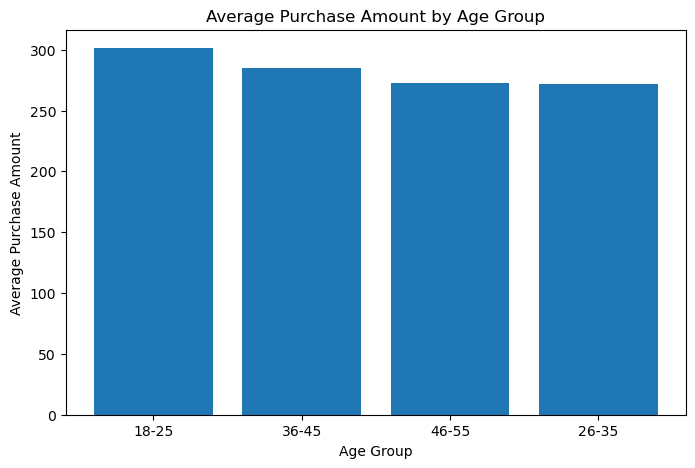

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(age_group_summary['Age_Group'], age_group_summary['Purchase_Amount'])
plt.title('Average Purchase Amount by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Purchase Amount')
plt.show()


##### Top 5 best-selling categories with very few returns

In [105]:

category_freq_low_return = (
    df.groupby('Purchase_Category')[['Return_Rate', 'Frequency_of_Purchase']]
      .mean()
      .sort_values(by=['Frequency_of_Purchase', 'Return_Rate'], ascending=[False, True])
)

print(category_freq_low_return)

top5 = category_freq_low_return.head(5)


                          Return_Rate  Frequency_of_Purchase
Purchase_Category                                           
Furniture                    1.000000               6.529412
Animal Feed                  0.928571               6.035714
Baby Products                1.000000               5.944444
Clothing                     1.000000               5.789474
Gardening & Outdoors         1.172414               5.620690
Luxury Goods                 0.952381               5.619048
Food & Beverages             0.782609               5.565217
Toys & Games                 0.740741               5.555556
Travel & Leisure Flights     1.130435               5.478261
Books                        1.200000               5.400000
Electronics                  1.029412               5.382353
Sports & Outdoors            1.031250               5.343750
Health Care                  0.708333               5.333333
Arts & Crafts                0.695652               5.304348
Health Supplements      

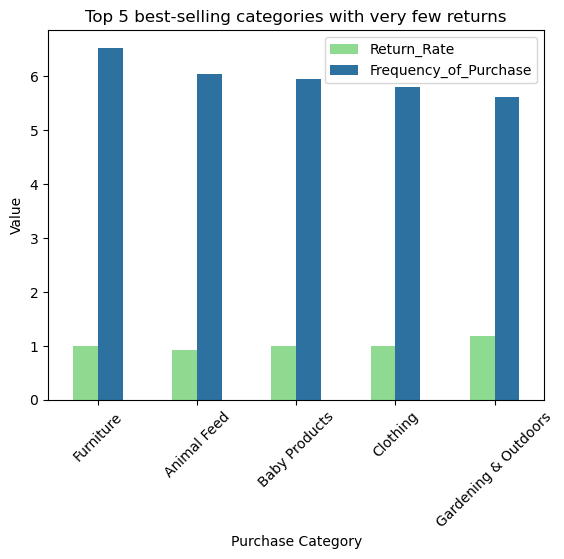

In [106]:
import matplotlib.pyplot as plt
top5.plot(kind='bar', color=["#8FDA91", "#2C719F"])

plt.title('Top 5 best-selling categories with very few returns')
plt.xlabel('Purchase Category')
plt.ylabel('Value')
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()


##### Top 10 locations by most purchasing

Location
Al Jīzah       17.0
Tewulike       15.0
Magdalena      15.0
Pho Duc        14.0
Colima         13.0
               ... 
Vabalninkas     2.0
Bugarama        2.0
Kouvola         2.0
Chabařovice     2.0
Boundiali       2.0
Name: Frequency_of_Purchase, Length: 566, dtype: float64


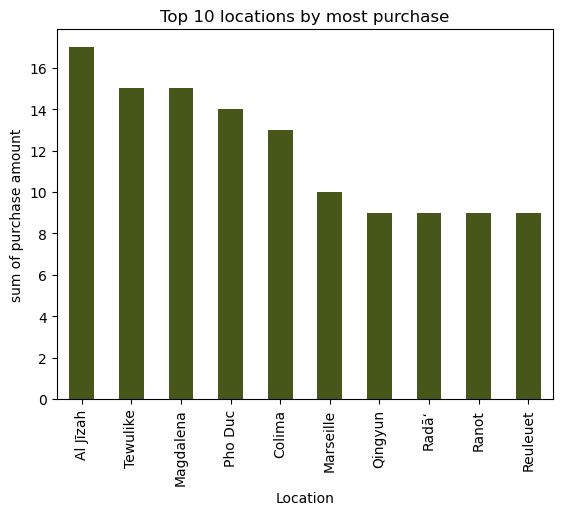

In [107]:
sales_by_loc=df.groupby('Location')['Frequency_of_Purchase'].sum().sort_values(ascending=False)
print(sales_by_loc)
sales_by_loc.head(10).plot(kind='bar',color="#3C4D0BF1")
plt.title('Top 10 locations by most purchase')
plt.xlabel('Location')
plt.ylabel('sum of purchase amount')
plt.show()

In [108]:
# Step 1: Find top 10 locations by total purchase frequency
top_10_locations = (
    df.groupby('Location')['Frequency_of_Purchase']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .index
)

# Step 2: Filter data for only top 10 locations
top_location_data = df[df['Location'].isin(top_10_locations)]

# Step 3: Find most frequently purchased category in each top location
top_category_per_top_location = (
    top_location_data
    .groupby(['Location', 'Purchase_Category'])['Frequency_of_Purchase']
    .mean()
    .reset_index()
    .loc[
        lambda x: x.groupby('Location')['Frequency_of_Purchase'].idxmax()
    ]
    .sort_values(by='Frequency_of_Purchase', ascending=False)
)

print(top_category_per_top_location)


     Location     Purchase_Category  Frequency_of_Purchase
0    Al Jīzah           Animal Feed                    9.0
2      Colima         Arts & Crafts                    9.0
9     Qingyun      Food & Beverages                    9.0
10      Radā‘             Furniture                    9.0
11      Ranot              Clothing                    9.0
12   Reuleuet           Electronics                    9.0
13   Tewulike           Electronics                    9.0
4   Magdalena  Gardening & Outdoors                    8.0
8     Pho Duc           Electronics                    7.0
6   Marseille  Gardening & Outdoors                    5.0


In [109]:
import pandas as pd

# Step 1: Convert to datetime
df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'])

# Step 2: Extract month
df['Purchase_Month'] = df['Time_of_Purchase'].dt.month

# Step 3: Monthly frequency per product category
monthly_category_freq = (
    df.groupby(['Purchase_Month', 'Purchase_Category'])['Frequency_of_Purchase']
      .sum()
      .reset_index()
)

# Step 4: MOST frequently purchased product category in each month
top_category_each_month = (
    monthly_category_freq
    .loc[
        monthly_category_freq.groupby('Purchase_Month')['Frequency_of_Purchase'].idxmax()
    ]
    .sort_values('Purchase_Month')
)

print(top_category_each_month)




     Purchase_Month         Purchase_Category  Frequency_of_Purchase
18                1  Travel & Leisure Flights                   32.0
29                2           Home Appliances                   20.0
44                3                     Books                   40.0
66                4          Food & Beverages                   25.0
96                5           Home Appliances                   25.0
113               6           Home Appliances                   22.0
144               7              Toys & Games                   34.0
153               8      Gardening & Outdoors                   35.0
167               9               Electronics                   39.0
189              10      Gardening & Outdoors                   33.0
200              11               Animal Feed                   30.0
232              12              Luxury Goods                   27.0


C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\848629484.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Time_of_Purchase'] = pd.to_datetime(df['Time_of_Purchase'])
C:\Users\AJAI\AppData\Local\Temp\ipykernel_2088\848629484.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Purchase_Month'] = df['Time_of_Purchase'].dt.month


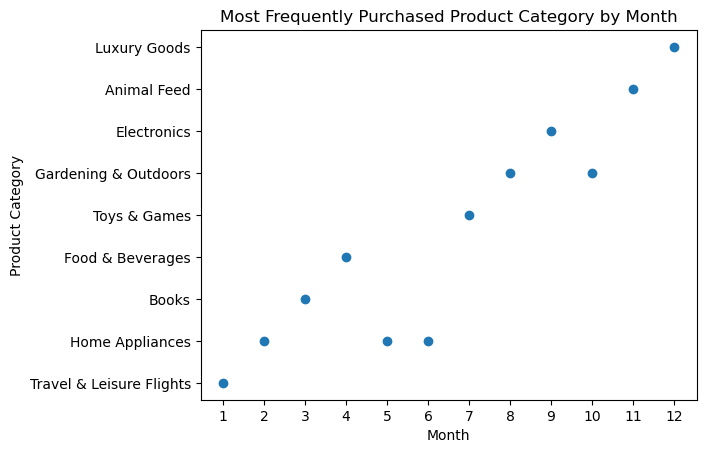

In [110]:

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(
    top_category_each_month['Purchase_Month'],
    top_category_each_month['Purchase_Category']
)

plt.title('Most Frequently Purchased Product Category by Month')
plt.xlabel('Month')
plt.ylabel('Product Category')
plt.xticks(range(1, 13))
plt.show()
